# 4. Feature Engineering
В этом ноутбуке мы рассмотрим и применим процесс генерации признаков (Feature Engineering), используя разработанный `CraigslistFeatureEngineer`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import CraigslistFeatureEngineer

sns.set_theme(style="whitegrid")

## Загрузка данных

In [2]:
data_path = Path("../data/interim/train_filtered.csv")
df = pd.read_csv(data_path, index_col=0)

print("Размер датасета:", df.shape)
df.head(3)

Размер датасета: (182244, 19)


,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,description,state,lat,long,posting_date
0,richmond,19500,2015.0,honda,cr-v,like new,NaN,gas,61000.0,clean,automatic,NaN,NaN,NaN,*Serious Buyers only* *Clean Title* Only...,va,37.674539,-77.590942,2021-04-23T18:04:22-0400
1,sacramento,22590,2018.0,mercedes-benz,cla 250 coupe 4d,good,NaN,other,53090.0,clean,other,fwd,coupe,black,Carvana is the safer way to buy a car During t...,ca,38.580000,-121.490000,2021-05-03T15:30:57-0700
2,detroit metro,34900,2016.0,lexus,rx 350,like new,6 cylinders,gas,19231.0,clean,automatic,4wd,SUV,grey,Engine: 3.5L V6 DOHC 24V VVT-iW 2.277 Axle Rat...,mi,42.197416,-83.273364,2021-04-29T14:17:37-0400


## 1. Инициализация Feature Engineer
`CraigslistFeatureEngineer` включает в себя логику для:
1. Возраста машины (`car_age`)
2. Логарифма одометра (`log_odometer`)
3. Обработки пропусков категориальных признаков (unknown)
4. Группировки редких моделей и производителей
5. Извлечения признаков региона и цвета (ценовые кластеры)

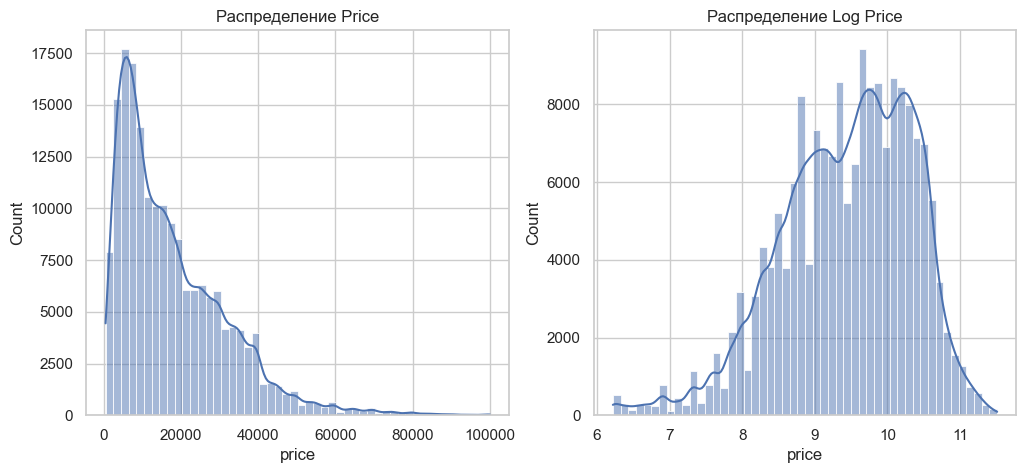

In [3]:
X = df.drop(columns=["price"]).copy()
y = df["price"].copy()

# 1. Логарифм цены (будет использоваться при обучении)
# Мы сохраним его в датасет для наглядности распределения
log_price = np.log1p(y)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(y, bins=50, kde=True)
plt.title("Распределение Price")

plt.subplot(1, 2, 2)
sns.histplot(log_price, bins=50, kde=True)
plt.title("Распределение Log Price")
plt.show()

In [4]:
# Применяем CraigslistFeatureEngineer
fe = CraigslistFeatureEngineer(model_min_count=20, region_n_clusters=10, paint_n_clusters=5)
fe.fit(X, y)
X_features = fe.transform(X)

## 2. Возраст машины (`car_age`)

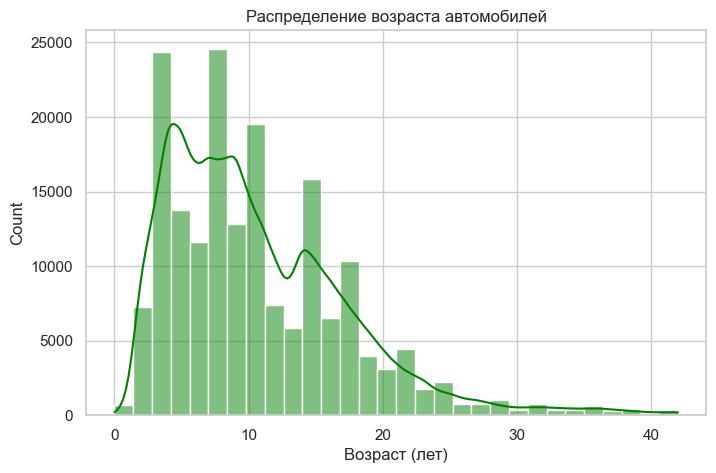

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(X_features["car_age"], bins=30, kde=True, color='green')
plt.title("Распределение возраста автомобилей")
plt.xlabel("Возраст (лет)")
plt.show()

## 3. Обработка категориальных признаков и пропусков
Пропуски в condition, drive, cylinders и других были заполнены. Text cylinders переведены в числа.

In [6]:
print("Пропуски после FE:")
print(X_features[["condition", "drive", "cylinders"]].isna().sum())
X_features[["condition", "drive", "cylinders"]].head()

Пропуски после FE:
condition    0
drive        0
cylinders    0
dtype: int64


,condition,drive,cylinders
0,like new,unknown,0
1,good,fwd,0
2,like new,4wd,6
3,like new,4wd,6
4,excellent,rwd,0


## 4. Группировка редких категорий (Model)
Редкие модели были сгруппированы в категорию `other`.

In [7]:
print("Уникальных моделей ДО:", df["model"].nunique())
print("Уникальных моделей ПОСЛЕ:", X_features["model"].nunique())

# Топ-10 моделей после трансформации
X_features["model"].value_counts().head(10)

Уникальных моделей ДО: 20266
Уникальных моделей ПОСЛЕ: 1356


model
other             49297
f-150              3097
silverado 1500     2056
unknown            2031
1500               1665
camry              1465
accord             1465
silverado          1432
civic              1361
altima             1208
Name: count, dtype: int64

## 5. Признаки по региону (Region Price Clusters)
Вместо ~400 уникальных регионов мы сгруппировали их в 10 ценовых кластеров.

C:\Users\Alex\AppData\Local\Temp\ipykernel_2668\3127946457.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="viridis")


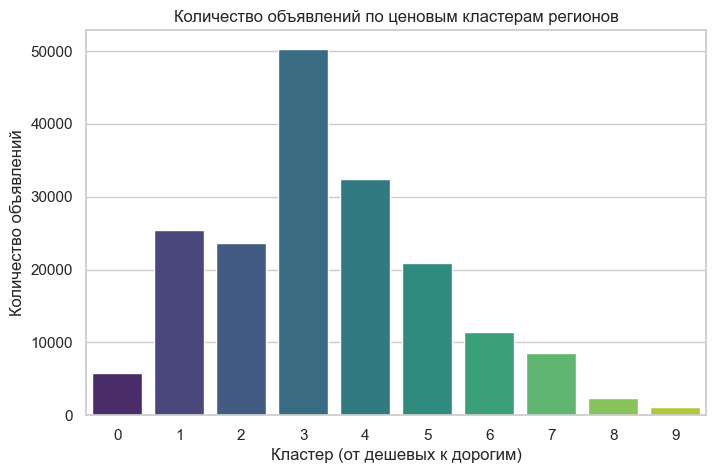

In [8]:
cluster_counts = X_features["region_price_cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="viridis")
plt.title("Количество объявлений по ценовым кластерам регионов")
plt.xlabel("Кластер (от дешевых к дорогим)")
plt.ylabel("Количество объявлений")
plt.show()

## Сохранение обработанных данных
Сохраним полученные признаки для дальнейшего обучения (хотя в реальном пайплайне трансформатор встраивается в `Pipeline`).

In [9]:
# Сохраняем в processed
X_features["price"] = y
X_features.to_csv("../data/processed/train_features.csv")
print("Данные успешно сохранены в data/processed/train_features.csv")

Данные успешно сохранены в data/processed/train_features.csv
